In [28]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [29]:
#Train dataset and test dataset
train_dataset = torchvision.datasets.FashionMNIST(root='.', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='.', train=False, transform=transforms.ToTensor(), download=True)

In [30]:
#Data attributes
print(f'Shape of dataset {train_dataset.data.shape}')
print(f'Max {train_dataset.data.max()}')
print(f'Targets {train_dataset.targets}')
print(f'Number of classes: {len(set(train_dataset.targets.numpy()))}')

Shape of dataset torch.Size([60000, 28, 28])
Max 255
Targets tensor([9, 0, 0,  ..., 3, 0, 5])
Number of classes: 10


In [31]:
K = len(set(train_dataset.targets.numpy()))
K

10

In [32]:
class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2),
            nn.ReLU()
        )

        self.dense_layers = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(128 * 2 * 2, 512),  # adjust this if input image size changes
            nn.ReLU(),
            nn.Linear(512, K)
        )

    def forward(self, X):
        out = self.conv_layers(X)
        out = out.view(out.size(0), -1)
        out = self.dense_layers(out)
        return out

In [33]:
model = CNN(K)

In [34]:
#Same model but with flatten
#model = nn.Sequential(
#    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2),
#    nn.ReLU(),
#    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2),
#    nn.ReLU(),
#    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2),
#    nn.ReLU(),
#    nn.Flatten(),
#    nn.Dropout(0.2),
#    nn.Linear(128*2*2, 512),
#    nn.ReLU(),
#    nn.Linear(512, K)
#   
#)

In [35]:
device = torch.device('mps')
model.to(device)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
    (5): ReLU()
  )
  (dense_layers): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=512, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [36]:
#Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [37]:
#Data loader
batch_size = 128

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [38]:
#Training loop
def batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs):
    train_losses = np.zeros(epochs)
    test_losses = np.zeros(epochs)
    
    for i in range(epochs):
        model.train()
        t0 = datetime.now()
        train_loss = []
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            #Zero the parameters grad
            optimizer.zero_grad()
            
            #Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets) 
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            
        train_loss = np.mean(train_loss)
        
        model.eval()
        test_loss = []
        
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            #Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets) 
            test_loss.append(loss.item())
            
        test_loss = np.mean(test_loss)
        
        #Save losses
        train_losses[i] = train_loss
        test_losses[i] = test_loss
        
        dt = datetime.now() - t0
        
        print(f'Epoch {i+1}/{epochs}, Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, Duration: {dt}')
    return train_losses, test_losses 

In [39]:
train_losses, test_losses = batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs=15)

Epoch 1/15, Train loss: 0.6479, Test loss: 0.4913, Duration: 0:00:05.873736
Epoch 2/15, Train loss: 0.4347, Test loss: 0.4004, Duration: 0:00:04.685514
Epoch 3/15, Train loss: 0.3747, Test loss: 0.3594, Duration: 0:00:04.620335
Epoch 4/15, Train loss: 0.3387, Test loss: 0.3368, Duration: 0:00:04.663063
Epoch 5/15, Train loss: 0.3105, Test loss: 0.3313, Duration: 0:00:04.453781
Epoch 6/15, Train loss: 0.2870, Test loss: 0.3180, Duration: 0:00:04.530411
Epoch 7/15, Train loss: 0.2684, Test loss: 0.2973, Duration: 0:00:04.430480
Epoch 8/15, Train loss: 0.2526, Test loss: 0.2955, Duration: 0:00:04.710252
Epoch 9/15, Train loss: 0.2369, Test loss: 0.2887, Duration: 0:00:04.552239
Epoch 10/15, Train loss: 0.2217, Test loss: 0.2838, Duration: 0:00:04.564791
Epoch 11/15, Train loss: 0.2110, Test loss: 0.2848, Duration: 0:00:04.571598
Epoch 12/15, Train loss: 0.1976, Test loss: 0.2881, Duration: 0:00:04.918631
Epoch 13/15, Train loss: 0.1841, Test loss: 0.2913, Duration: 0:00:04.715398
Epoch 14

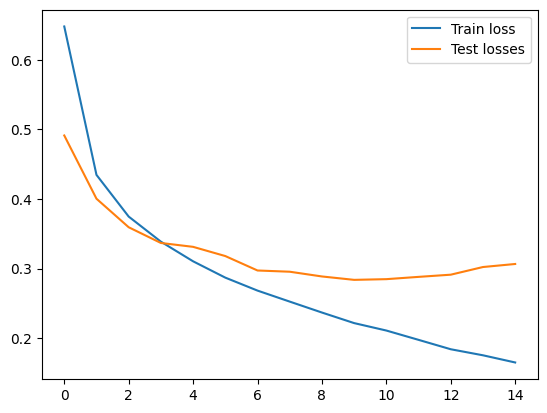

In [41]:
plt.plot(train_losses, label = 'Train loss')
plt.plot(test_losses, label = 'Test losses')
plt.legend()
plt.show()

In [45]:
# Evaluate model accuracy on training and test sets

# -------- Training Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in train_loader:
    # Move data to device (CPU or GPU)
    inputs, targets = inputs.to(device), targets.to(device)

    # Get model predictions
    outputs = model(inputs)

    # Get predicted class (highest score)
    _, predictions = torch.max(outputs, 1)

    # Count correct predictions
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate training accuracy
train_acc = n_correct / n_total

# -------- Testing Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)
    _, predictions = torch.max(outputs, 1)
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate test accuracy
test_acc = n_correct / n_total

# Print results
print(f'Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}')


Train acc: 0.9510, Test acc: 0.8986


In [52]:
# Plot confusion matrix for classification results
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plots a confusion matrix.

    Parameters:
    - cm: confusion matrix (2D array)
    - classes: list of class labels
    - normalize: whether to normalize values
    - title: title of the plot
    - cmap: color map used for the plot
    """
    
    # Normalize the matrix if requested
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix without normalization')

    print(cm)

    # Display the matrix as an image
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Set up tick marks and labels
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Format each cell
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    # Final layout settings
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Confusion matrix without normalization
[[872   0  30  16   2   1  69   0  10   0]
 [  1 977   0  16   1   0   2   0   3   0]
 [ 16   1 915   8  25   0  31   0   4   0]
 [ 12   2  22 923  21   0  16   0   4   0]
 [  0   1 112  33 789   0  58   0   7   0]
 [  0   0   0   1   0 977   0  13   4   5]
 [116   1 119  31  74   0 635   0  24   0]
 [  0   0   0   0   0  11   0 956   1  32]
 [  1   1   6   2   1   1   2   0 985   1]
 [  1   0   0   0   0   6   0  34   2 957]]


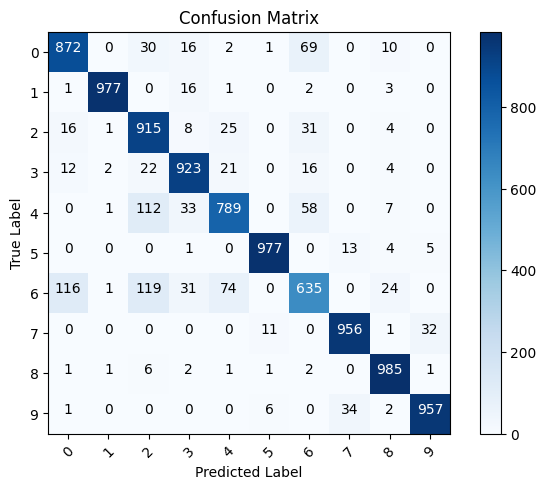

In [54]:
x_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()
p_test = np.array([])

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    
    #Forward pass
    outputs = model(inputs)
    
    #Predictions 
    _, predictions = torch.max(outputs, 1)
    
    #Update p_test
    p_test = np.concatenate((p_test, predictions.cpu().numpy()))
    
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))